# Preprocesamiento y EDA — Clasificación del nivel de adicción al videojuego

Este notebook documenta un flujo **reproducible** para explorar la data cruda, evaluar **calidad**, entender el comportamiento de las variables y construir un tabular listo para **modelos de clasificación** que predigan el **nivel de adicción**.

**Variable objetivo (negocio):** grado de adicción autodeclarado / sintético en escala continua `addiction_level` (0–10 en este dataset). Para clasificación supervisada, definiremos clases ordinales derivadas por **cuartiles** (cuatro clases equilibradas), etiquetadas de menor a mayor severidad.

**Salida:** al finalizar, se guarda un CSV en `data_preprocesada/` y un pequeño reporte JSON con metadatos del preprocesamiento.

> **Nota:** La columna continua `addiction_level` se **excluye** de los predictores al entrenar modelos, para evitar *data leakage* (sería un predictor casi perfecto de la propia etiqueta discretizada).

## 1. Imports y estilo de gráficos

**Qué hace este bloque:** carga librerías estándar para datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`) y utilidades de *machine learning* (`sklearn`). También fija semillas y el estilo visual para que las figuras sean legibles en informes.

**Por qué importa:** un EDA profesional exige gráficos consistentes (tipografía, contraste) y resultados reproducibles (`RANDOM_STATE`).

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

try:
    import missingno as msno
except ModuleNotFoundError:
    msno = None  # pip install missingno

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Rutas del proyecto

**Qué hace:** localiza la raíz del repo buscando `Data_cruda/` y `requirements.txt`, sin depender solo de `Path.cwd()` (en Cursor/Jupyter el *cwd* del kernel a veces apunta a una carpeta ya borrada → `FileNotFoundError`). Usa `ipynbname`, variables de entorno y `os.chdir(ROOT)` para dejar el proceso en un directorio válido.

**Si aún falla:** reinicia el kernel, `cd` en terminal a la raíz del repo, o ejecuta antes `import os; os.environ["REPO_ROOT"] = "/ruta/absoluta/al/repo"`.

In [2]:
import os


def find_repo_root() -> Path:
    """Evita depender solo de Path.cwd(): el kernel puede tener un cwd borrado o movido (Errno 2)."""
    env_root = os.environ.get("REPO_ROOT")
    if env_root:
        r = Path(env_root).expanduser().resolve()
        if (r / "Data_cruda").is_dir():
            return r

    def climb(start: Path) -> Path | None:
        cur = start.resolve()
        for _ in range(35):
            if (cur / "Data_cruda").is_dir() and (cur / "requirements.txt").is_file():
                return cur
            if cur.parent == cur:
                break
            cur = cur.parent
        return None

    seeds: list[Path] = []
    try:
        import ipynbname

        nb_path = ipynbname.path()
        if nb_path is not None:
            seeds.append(nb_path.parent)
            if nb_path.parent.name.lower() == "notebooks":
                seeds.append(nb_path.parent.parent)
    except Exception:
        pass
    try:
        seeds.append(Path.cwd())
    except FileNotFoundError:
        pass
    for var in ("PWD", "JUPYTER_SERVER_ROOT"):
        v = os.environ.get(var)
        if v:
            p = Path(v).expanduser()
            try:
                if p.exists():
                    seeds.append(p)
            except OSError:
                pass
    try:
        from IPython import get_ipython

        ip = get_ipython()
        if ip is not None:
            wd = ip.run_line_magic("pwd", "")
            if wd:
                p = Path(wd).expanduser()
                if p.exists():
                    seeds.append(p)
    except Exception:
        pass

    seen: set[Path] = set()
    for s in seeds:
        try:
            rs = s.resolve()
        except (OSError, FileNotFoundError, RuntimeError):
            continue
        if rs in seen or not rs.exists():
            continue
        seen.add(rs)
        found = climb(rs)
        if found is not None:
            return found

    raise FileNotFoundError(
        "No se encontró la raíz del repo (Data_cruda/ + requirements.txt). "
        "Reinicia el kernel, abre una terminal en la raíz del proyecto y vuelve a ejecutar, "
        "o ejecuta antes: import os; os.environ['REPO_ROOT'] = '/ruta/al/repo/ciencia_de_datos'"
    )


ROOT = find_repo_root()
try:
    os.chdir(ROOT)
except OSError:
    pass

DIR_CRUDA = ROOT / "Data_cruda"
DIR_OUT = ROOT / "data_preprocesada"
DIR_OUT.mkdir(parents=True, exist_ok=True)

RAW_GZ = DIR_CRUDA / "gaming_mental_health_10M_40features.csv.gz"
OUT_CSV = DIR_OUT / "dataset_preprocesado_clasificacion.csv"
OUT_REPORT = DIR_OUT / "preprocessing_report.json"

print("ROOT:", ROOT.resolve())
print("Entrada:", RAW_GZ)
print("Salida CSV:", OUT_CSV)

ROOT: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos
Entrada: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Data_cruda/gaming_mental_health_10M_40features.csv.gz
Salida CSV: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/data_preprocesada/dataset_preprocesado_clasificacion.csv


## 3. Carga del dataset crudo

**Qué hace:** lee el CSV comprimido con `gzip`. El archivo contiene ~1 millón de filas; en hardware limitado podrías usar `nrows=` para pruebas.

**Interpretación esperada:** cada fila es un individuo sintético/observado con métricas de conducta de juego, salud mental y estilo de vida. La calidad del modelo downstream depende de que no haya duplicados triviales, valores fuera de rango o fugas de información.

In [3]:
if not RAW_GZ.is_file():
    raise FileNotFoundError(
        f"No se encontró el archivo crudo en {RAW_GZ}. "
        "Coloca el .csv.gz en Data_cruda/ (p. ej. extrayéndolo de la rama main)."
    )

df = pd.read_csv(RAW_GZ, compression="gzip", low_memory=False)
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (1000000, 39)


,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,addiction_level,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,4.06,5.02,7.85,9.55,68.80,77.12,2.02,0.39,0.05,0.51,0.23,0.32,1.50,20,186,2.82,1,1,1746.97,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,6.76,7.63,7.06,6.96,38.11,44.94,5.85,0.23,0.37,0.43,0.24,0.32,17.93,37,21,1.34,8,1,342.04,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,9.57,4.02,1.12,2.61,97.44,54.77,0.08,0.06,0.15,0.48,0.27,0.42,2.99,45,146,3.56,8,1,57.95,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,4.97,1.40,6.59,6.00,67.65,88.56,2.77,0.53,0.36,0.64,0.57,0.82,1.99,11,133,1.80,6,1,617.32,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,8.73,4.83,6.03,3.54,62.34,68.82,3.37,0.78,0.25,0.29,0.47,0.83,9.23,24,399,1.30,4,0,1398.39,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


## 4. Tipos de datos, resumen estadístico y primeras anomalías

**Qué hace:** `info()` muestra tipos y memoria; `describe()` resume centrality y dispersión para numéricas.

**Cómo interpretar:** buscamos variables con escalas muy distintas (hará falta escalado en modelos lineales/SVM), asimetrías fuertes (*skew*) y rangos sospechosos (p. ej. proporciones fuera de [0,1]).

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 39 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   age                         1000000 non-null  int64  
 1   gender                      1000000 non-null  str    
 2   income                      1000000 non-null  int64  
 3   daily_gaming_hours          1000000 non-null  float64
 4   weekly_sessions             1000000 non-null  int64  
 5   years_gaming                1000000 non-null  int64  
 6   sleep_hours                 1000000 non-null  float64
 7   caffeine_intake             1000000 non-null  float64
 8   exercise_hours              1000000 non-null  float64
 9   stress_level                1000000 non-null  int64  
 10  anxiety_score               1000000 non-null  float64
 11  depression_score            1000000 non-null  float64
 12  social_interaction_score    1000000 non-null  float64
 13  relations

In [5]:
df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,35.9860,13.5572,13.00,24.00,36.00,48.00,59.00
income,1000000.0,77497.6760,41851.5405,5000.00,41258.00,77521.00,113697.00,149999.00
daily_gaming_hours,1000000.0,3.9993,2.8263,0.00,1.92,3.36,5.38,30.42
weekly_sessions,1000000.0,19.9975,11.2534,1.00,10.00,20.00,30.00,39.00
years_gaming,1000000.0,12.0025,7.2078,0.00,6.00,12.00,18.00,24.00
sleep_hours,1000000.0,7.0005,1.5011,-0.17,5.99,7.00,8.01,14.02
caffeine_intake,1000000.0,1.9975,1.9962,0.00,0.58,1.39,2.77,26.90
exercise_hours,1000000.0,1.9990,1.9995,0.00,0.58,1.39,2.77,26.48
stress_level,1000000.0,5.4976,2.8732,1.00,3.00,5.00,8.00,10.00
anxiety_score,1000000.0,4.9986,1.9777,0.00,3.65,5.00,6.35,10.00


## 5. Calidad: valores faltantes, duplicados y cardinalidad

**Qué hace:** cuenta `NA` por columna, filas duplicadas y número de valores únicos (especialmente en `gender` y `addiction_level`).

**Decisiones típicas:** si hubiera muchos faltantes, imputaríamos o eliminaríamos según mecanismo (MCAR/MAR/MNAR). Aquí documentamos el estado real del archivo.

In [6]:
missing_per_col = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_per_col / len(df) * 100).round(4)
qc_missing = pd.DataFrame({"n_missing": missing_per_col, "pct": missing_pct})
qc_missing = qc_missing[qc_missing["n_missing"] > 0]
print("Columnas con al menos un faltante:")
display(qc_missing if len(qc_missing) else "Ninguna.")

dup_mask = df.duplicated()
n_dup = int(dup_mask.sum())
print(f"Filas duplicadas (todas las columnas): {n_dup} ({100 * n_dup / len(df):.4f}%)")

print("Cardinalidad addiction_level (muestra de únicos):", df["addiction_level"].nunique())
print("Valores de gender:", df["gender"].value_counts())

Columnas con al menos un faltante:


'Ninguna.'

Filas duplicadas (todas las columnas): 0 (0.0000%)
Cardinalidad addiction_level (muestra de únicos): 1001
Valores de gender: gender
Male      480581
Female    479579
Other      39840
Name: count, dtype: int64


### Visualización de ausencias (`missingno`)

**Qué hace:** matriz de presencia/ausencia. Si no hay huecos, el gráfico será uniforme — eso también es una **señal de calidad** (o de datos ya imputados en origen).

**Interpretación:** patrones en bloques pueden indicar censura o errores de integración.

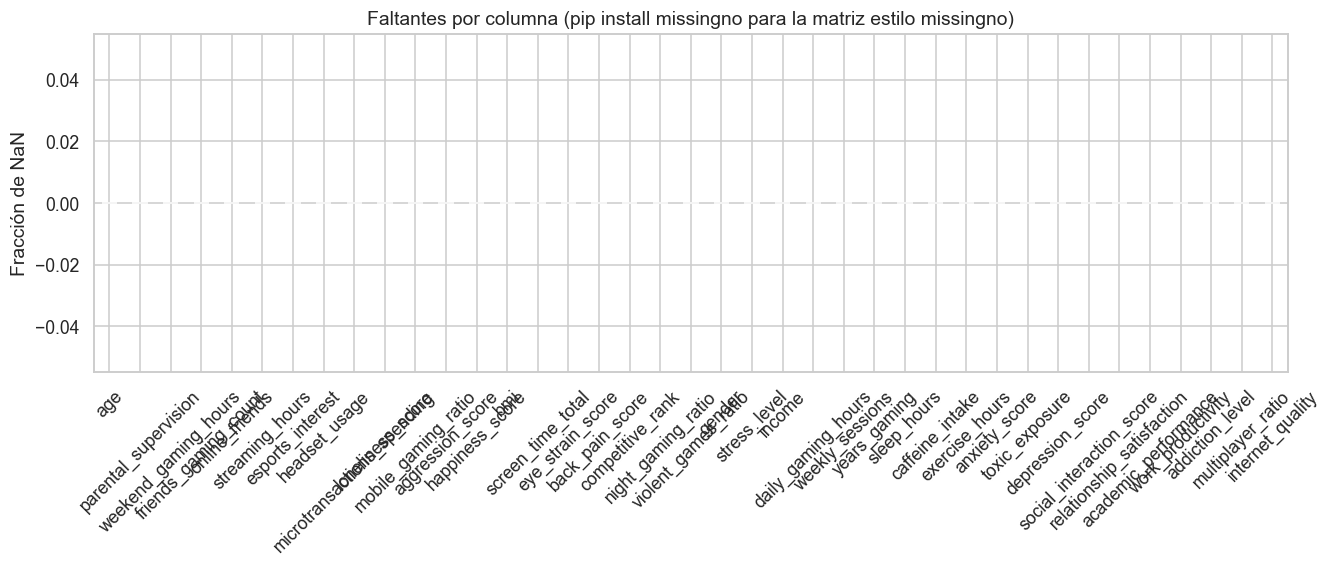

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
sample_m = df.sample(min(50_000, len(df)), random_state=RANDOM_STATE)
if msno is not None:
    msno.matrix(sample_m, ax=ax, sparkline=False)
    title = "Matriz de completitud (submuestra hasta 50k filas)"
else:
    miss_rate = df.isna().mean().sort_values(ascending=False)
    miss_rate.plot(kind="bar", ax=ax, color="#3182bd")
    ax.set_ylabel("Fracción de NaN")
    ax.tick_params(axis="x", rotation=45)
    title = "Faltantes por columna (pip install missingno para la matriz estilo missingno)"
ax.set_title(title)
plt.show()

## 6. Variable objetivo continua `addiction_level`

**Contexto:** en clasificación necesitamos etiquetas discretas. Primero exploramos la distribución continua para justificar el umbral o la regla de discretización.

**Herramientas:** histograma + KDE (densidad), boxplot global y estadísticos de forma (*skewness*, *kurtosis*).

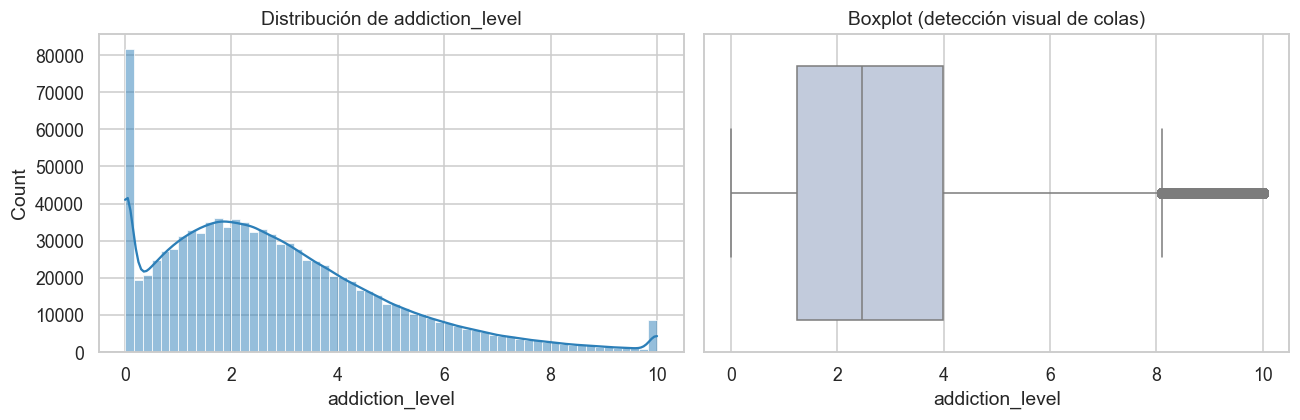

Asimetría (skew): 0.9487 | Curtosis exceso (Fisher): 0.7944


In [8]:
target_cont = df["addiction_level"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(target_cont, bins=60, kde=True, ax=axes[0], color="#2c7fb8")
axes[0].set_title("Distribución de addiction_level")
axes[0].set_xlabel("addiction_level")
sns.boxplot(x=target_cont, ax=axes[1], color="#bdc9e1")
axes[1].set_title("Boxplot (detección visual de colas)")
plt.tight_layout()
plt.show()

sk = float(stats.skew(target_cont, bias=False))
ku = float(stats.kurtosis(target_cont, fisher=True, bias=False))
print(f"Asimetría (skew): {sk:.4f} | Curtosis exceso (Fisher): {ku:.4f}")

**Interpretación:** una cola derecha (skew > 0) implica más personas con niveles bajos-moderados y una cola hacia adicción alta; eso es coherente con fenómenos de salud donde los extremos altos son menos frecuentes. La forma guía si usamos cortes por cuantiles (balance de clases) vs. cortes fijos clínicos (este dataset es sintético, así que usamos cuartiles con fines pedagógicos y de balance).

## 7. Definición de la etiqueta de clasificación

**Regla:** `addiction_class` = cuartiles de `addiction_level` con `pd.qcut`:
- **0 — Bajo:** Q0–Q25  
- **1 — Medio-bajo:** Q25–Q50  
- **2 — Medio-alto:** Q50–Q75  
- **3 — Alto:** Q75–Q100  

**Ventajas:** clases **casi equilibradas**, orden preservado, sin arbitrariedad de cortes fijos cuando no hay definición clínica externa.

**Limitación:** los límites dependen de la muestra; en producción convendría fijar cortes con política de negocio o datos históricos.

Filas tras eliminar duplicados exactos: 1000000 (eliminadas 0)
addiction_class
0    250544
1    249897
2    250653
3    248906
Name: count, dtype: int64
Proporciones:
 addiction_class
0    0.2505
1    0.2499
2    0.2507
3    0.2489
Name: count, dtype: float64


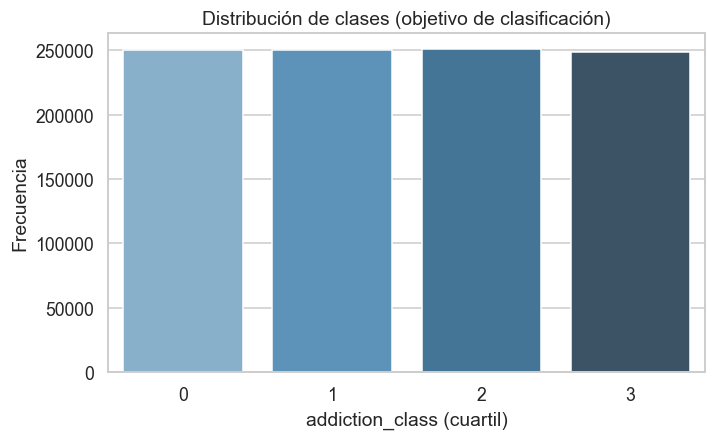

In [9]:
df_model = df.loc[~dup_mask].copy()
print(f"Filas tras eliminar duplicados exactos: {len(df_model)} (eliminadas {n_dup})")

labels_orden = ["Bajo", "Medio-bajo", "Medio-alto", "Alto"]
df_model["addiction_class"] = pd.qcut(
    df_model["addiction_level"],
    q=4,
    labels=False,
    duplicates="drop",
)

class_counts = df_model["addiction_class"].value_counts().sort_index()
print(class_counts)
print("Proporciones:\n", (class_counts / len(df_model)).round(4))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="Blues_d", ax=ax)
ax.set_xlabel("addiction_class (cuartil)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de clases (objetivo de clasificación)")
plt.show()

## 8. Variable categórica `gender`

**Qué hace:** cuenta por categoría y muestra proporciones.

**Siguiente paso:** codificación **one-hot** con `OneHotEncoder(drop="first")` para evitar multicolinealidad perfecta (*dummy variable trap*) en modelos lineales.

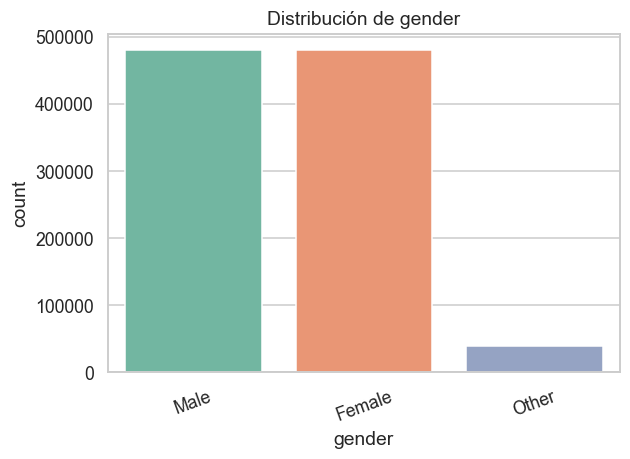

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
order = df_model["gender"].value_counts().index.tolist()
sns.countplot(data=df_model, x="gender", order=order, palette="Set2", ax=ax)
ax.set_title("Distribución de gender")
ax.set_xlabel("gender")
plt.xticks(rotation=20)
plt.show()

## 9. Exploración univariada de predictores numéricos clave

**Qué hace:** seleccionamos un subconjunto representativo (horas de juego, sueño, estrés, ratios, etc.) y graficamos histogramas.

**Interpretación:** multimodalidad o colas largas sugieren transformaciones (log) o *winsorización* en pasos posteriores.

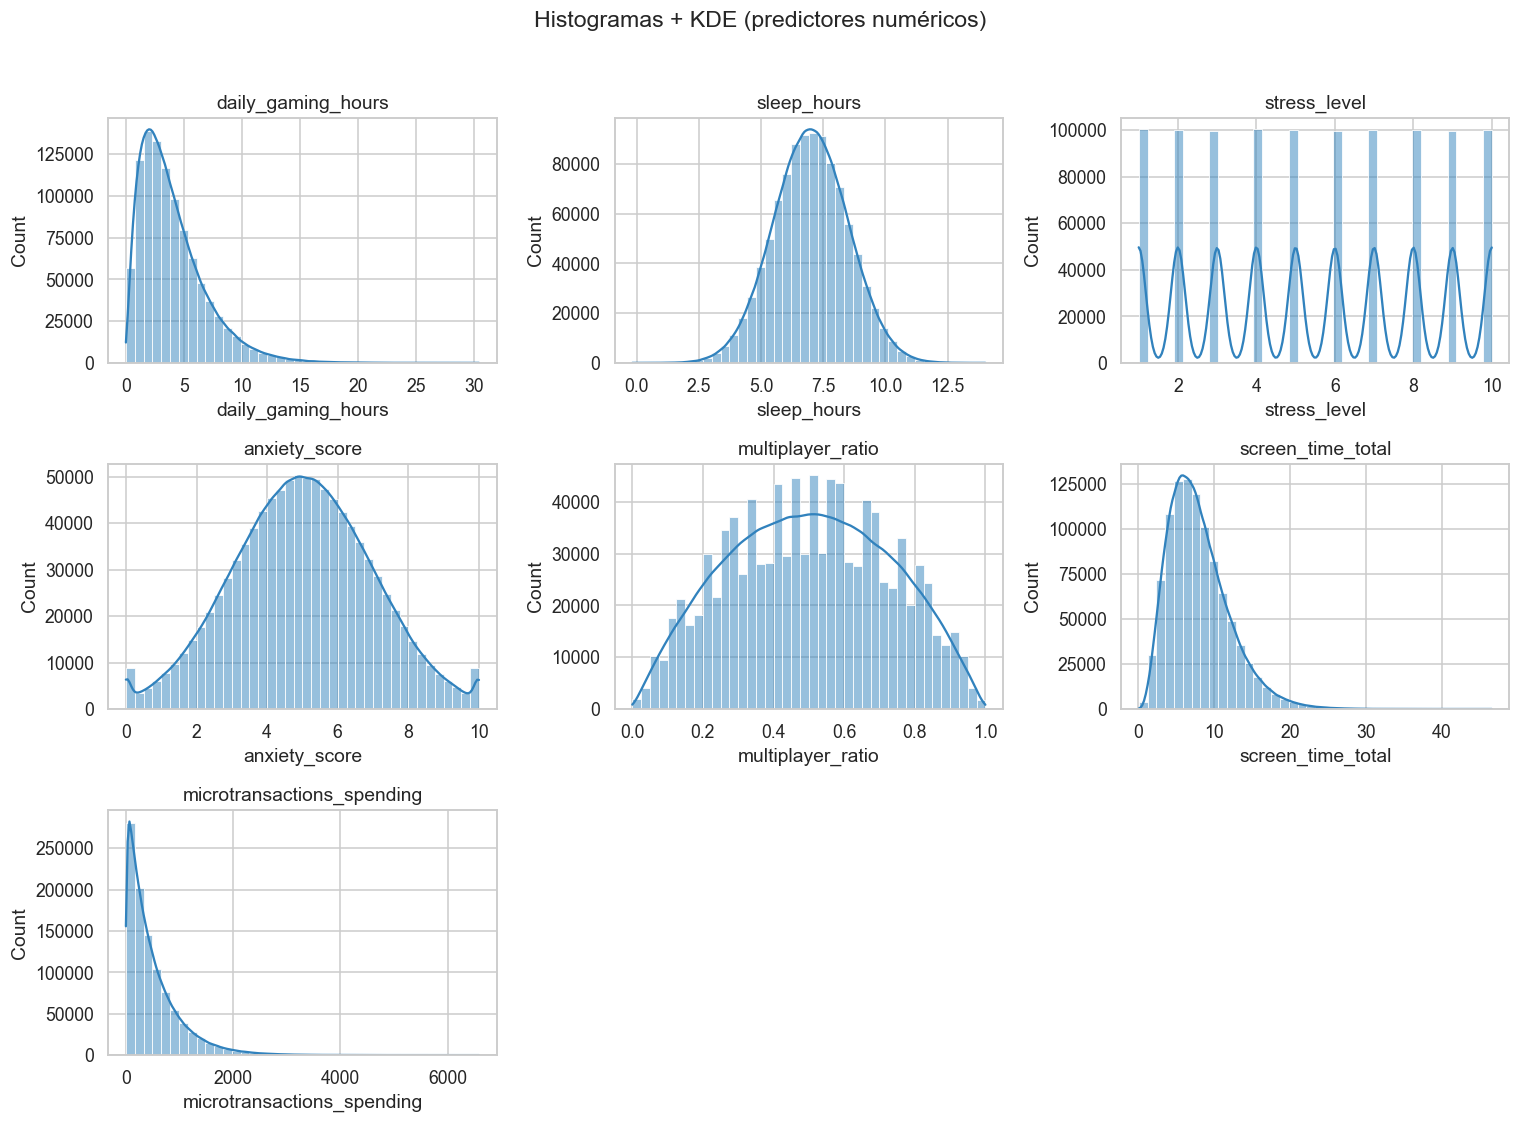

In [11]:
numeric_candidates = [
    c
    for c in df_model.select_dtypes(include=[np.number]).columns
    if c not in ("addiction_level", "addiction_class")
]
# Subconjunto legible para el notebook
plot_cols = [
    "daily_gaming_hours",
    "sleep_hours",
    "stress_level",
    "anxiety_score",
    "multiplayer_ratio",
    "screen_time_total",
    "microtransactions_spending",
]
plot_cols = [c for c in plot_cols if c in df_model.columns]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(plot_cols[:9]):
    sns.histplot(df_model[col].dropna(), bins=40, kde=True, ax=axes[i], color="#3182bd")
    axes[i].set_title(col)
for j in range(len(plot_cols), 9):
    axes[j].axis("off")
plt.suptitle("Histogramas + KDE (predictores numéricos)", y=1.02)
plt.tight_layout()
plt.show()

## 10. Relación bivariada: predictores vs. clase de adicción

**Qué hace:** *violin plots* para ver forma de la distribución condicional de variables fuertemente ligadas al juego frente a cada clase.

**Interpretación:** si las distribuciones se separan entre clases, el predictor tendrá poder discriminativo.

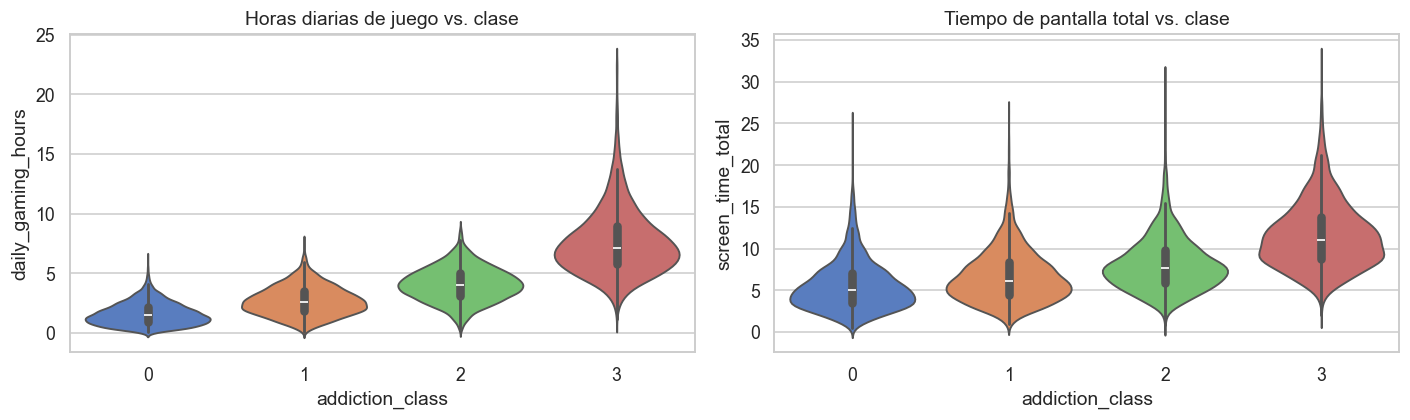

In [12]:
sample_v = df_model.sample(n=min(15_000, len(df_model)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.violinplot(data=sample_v, x="addiction_class", y="daily_gaming_hours", ax=axes[0], palette="muted")
axes[0].set_title("Horas diarias de juego vs. clase")
sns.violinplot(data=sample_v, x="addiction_class", y="screen_time_total", ax=axes[1], palette="muted")
axes[1].set_title("Tiempo de pantalla total vs. clase")
plt.tight_layout()
plt.show()

## 11. Correlación de Pearson entre variables numéricas

**Qué hace:** calcula la matriz de correlación en un subconjunto numérico (sin la etiqueta codificada todavía como entero categórico) para mapa de calor.

**Caveat:** correlación lineal no captura relaciones no lineales; sirve como **primer filtro** de redundancia (*multicolinearidad* leve es esperable en datos sociodemográficos).

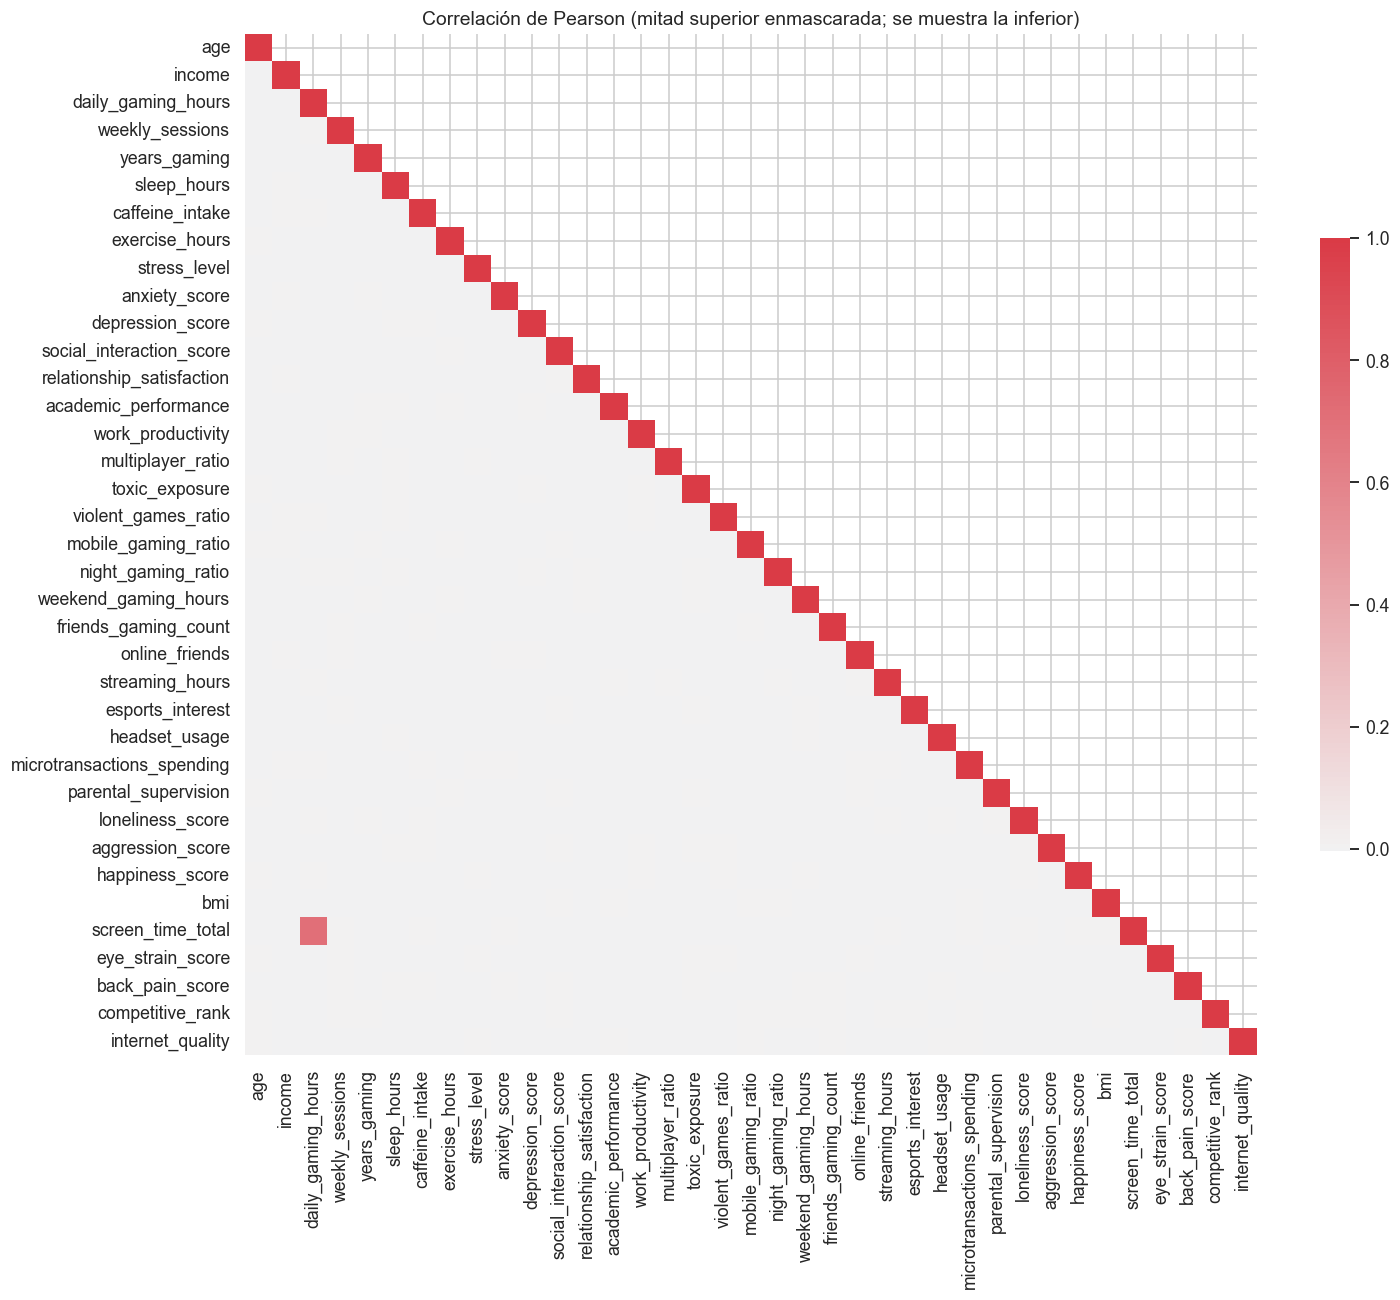

Top |corr| con addiction_level (continuo):


,corr
daily_gaming_hours,0.890923
screen_time_total,0.629738
caffeine_intake,0.002567
happiness_score,0.002534
toxic_exposure,-0.002007
back_pain_score,-0.001892
weekly_sessions,0.001546
age,-0.001467
parental_supervision,-0.001435
loneliness_score,0.001276


In [13]:
num_for_corr = df_model[numeric_candidates].copy()
# Muestra para acelerar si fuera necesario (aquí 1M x ~37 es aceptable en muchas máquinas)
corr = num_for_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(240, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    center=0,
    square=False,
    ax=ax,
    cbar_kws={"shrink": 0.6},
)
ax.set_title("Correlación de Pearson (mitad superior enmascarada; se muestra la inferior)")
plt.tight_layout()
plt.show()

target_corr = (
    df_model[numeric_candidates + ["addiction_level"]]
    .corr(numeric_only=True)["addiction_level"]
    .drop("addiction_level")
    .sort_values(key=abs, ascending=False)
)
print("Top |corr| con addiction_level (continuo):")
display(target_corr.head(12).to_frame("corr"))

**Lectura:** variables con alta correlación entre sí pueden redundar información; modelos basados en árboles toleran mejor la redundancia que regresión logística. Para modelos lineales, podría evaluarse VIF en un paso avanzado (fuera del alcance mínimo de este notebook).

## 12. Limpieza y transformación: *winsorización* por percentiles

**Justificación:** valores extremos pueden dominar escalados y algunos modelos. Recortamos cada predictor numérico al percentil **1% y 99%** calculado **en el mismo conjunto** (enfoque transversal tipo *cross-sectional*).

**Trade-off:** reduce influencia de outliers; también **comprime** variabilidad extrema. Documentamos los recortes en el reporte JSON.

> En un flujo estrictamente competitivo con holdout, los percentiles deberían calcularse **solo en entrenamiento** y aplicarse al test; aquí unificamos para entregar un único CSV tabular listo para `train_test_split` posterior en código de modelado.

In [14]:
FEATURE_NUMERIC = [c for c in numeric_candidates]


def winsorize_series(s: pd.Series, low: float = 0.01, high: float = 0.99) -> tuple[pd.Series, float, float]:
    lo, hi = s.quantile(low), s.quantile(high)
    return s.clip(lower=lo, upper=hi), float(lo), float(hi)


winsor_limits = {}
df_trans = df_model.copy()
for col in FEATURE_NUMERIC:
    new_s, lo, hi = winsorize_series(df_trans[col])
    df_trans[col] = new_s
    winsor_limits[col] = {"p01": lo, "p99": hi}

print("Ejemplo de límites (3 columnas):")
for c in FEATURE_NUMERIC[:3]:
    print(c, winsor_limits[c])

Ejemplo de límites (3 columnas):
age {'p01': 13.0, 'p99': 59.0}
income {'p01': 6461.0, 'p99': 148547.0}
daily_gaming_hours {'p01': 0.3, 'p99': 13.25}


## 13. Codificación de `gender` y ensamblado final

**Qué hace:**
1. Elimina la columna continua `addiction_level` de predictores (**anti-leakage**).
2. Aplica `OneHotEncoder(drop="first")` sobre `gender`.
3. Concatena matriz densa de features + columna objetivo `addiction_class`.

**Resultado:** tabla **solo numérica** compatible con `models/train_models.py` usando `--target addiction_class`.

In [15]:
X = df_trans.drop(columns=["addiction_level", "addiction_class"])
y = df_trans["addiction_class"].astype(int)

cat_cols = ["gender"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    verbose_feature_names_out=False,
)

X_enc = preprocess.fit_transform(X)
feature_names = list(preprocess.get_feature_names_out())

df_out = pd.DataFrame(X_enc, columns=feature_names, index=df_trans.index)
df_out["addiction_class"] = y.values

print("Shape final:", df_out.shape)
print("Columnas (primeras 15):", feature_names[:15], "...")
df_out.head()

Shape final: (1000000, 40)
Columnas (primeras 15): ['gender_Male', 'gender_Other', 'age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score', 'relationship_satisfaction'] ...


,gender_Male,gender_Other,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality,addiction_class
0,0.0,0.0,51.0,8615.0,3.68,22.0,17.0,5.26,1.00,0.18,3.0,4.06,5.02,7.85,9.55,68.80,77.12,0.39,0.05,0.51,0.23,0.32,1.50,20.0,186.0,2.82,1.0,1.0,1746.97,0.0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80.0,10.0,1
1,0.0,0.0,41.0,39453.0,5.70,34.0,16.0,9.20,0.70,1.44,8.0,6.76,7.63,7.06,6.96,38.11,44.94,0.23,0.37,0.43,0.24,0.32,17.93,37.0,21.0,1.34,8.0,1.0,342.04,7.0,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57.0,2.0,3
2,1.0,0.0,27.0,40466.0,1.58,8.0,22.0,7.39,2.24,3.15,3.0,9.57,4.02,1.36,2.61,97.44,54.77,0.06,0.15,0.48,0.27,0.42,2.99,45.0,146.0,3.56,8.0,1.0,57.95,9.0,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59.0,10.0,0
3,1.0,0.0,55.0,51076.0,6.11,39.0,24.0,7.99,1.65,2.80,1.0,4.97,1.40,6.59,6.00,67.65,88.56,0.53,0.36,0.64,0.57,0.82,1.99,11.0,133.0,1.80,6.0,1.0,617.32,5.0,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89.0,1.0,2
4,1.0,0.0,20.0,86116.0,3.65,17.0,0.0,7.12,1.02,1.01,2.0,8.73,4.83,6.03,3.54,62.34,68.82,0.78,0.25,0.29,0.47,0.83,9.23,24.0,399.0,1.30,4.0,0.0,1398.39,9.0,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15.0,10.0,2


## 14. Control de calidad del tabular final y guardado

**Qué hace:** verifica que no queden `NaN`, muestra conteo de clases y escribe:
- `data_preprocesada/dataset_preprocesado_clasificacion.csv`
- `data_preprocesada/preprocessing_report.json` con hiperparámetros y distribución de etiquetas.

In [16]:
assert df_out.isna().sum().sum() == 0, "Aún hay NaN en el tabular final."

report = {
    "n_rows": int(len(df_out)),
    "n_features": int(len(feature_names)),
    "target_column": "addiction_class",
    "class_labels": labels_orden,
    "class_distribution": df_out["addiction_class"].value_counts().sort_index().to_dict(),
    "winsorize_percentiles": {"low": 0.01, "high": 0.99},
    "winsor_limits_sample": {k: winsor_limits[k] for k in list(winsor_limits)[:5]},
    "duplicates_removed": n_dup,
    "random_state": RANDOM_STATE,
}

df_out.to_csv(OUT_CSV, index=False)
with open(OUT_REPORT, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("Guardado:", OUT_CSV)
print("Reporte:", OUT_REPORT)

Guardado: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/data_preprocesada/dataset_preprocesado_clasificacion.csv
Reporte: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/data_preprocesada/preprocessing_report.json


## 15. Próximos pasos (modelado)

Con el CSV generado puedes entrenar los cinco modelos definidos en `models/train_models.py`:

```bash
python models/train_models.py --data data_preprocesada/dataset_preprocesado_clasificacion.csv --target addiction_class
```

**Recordatorio:** las clases son cuartiles de severidad; interpreta métricas (accuracy, F1 macro, reporte por clase) en ese contexto ordinal-aproximado.